# Project Review & Documentation

**Auteur :** Mohamed Mehdi AKESBI

Le but de ce projet est de construire un pricer pour les options vanilles Call/Put Européens basé sur la formule de Black-Scholes, avec une introduction au calcul des **Greeks** pour finir avec une comparaison au modèle CRR.

Le déroulement de ce projet consistera en la lecture des chapitres d'intérêt du Hull (Options, Futures & other derivatives), puis implémentation des concepts en python. Enfin ce Notebook servira de support d'analyse et de commentaires.

In [7]:
import sys
import os

# On remonte d'un cran (..) et on pointe vers le dossier src
chemin_src = os.path.abspath('../src')

# On ajoute ce chemin aux chemins de recherche de Python
if chemin_src not in sys.path:
    sys.path.append(chemin_src)

## STEP 1

La première étape consiste à lire le chapitre 10 (Mechanics of Options and strategies) et implémenter les payoffs des différentes positions dans `src/strategies.py`.

Nous avons opté pour la vectorisation des paramètres (S: Spot, K: Strike) et donc l'issue des fonctions payoffs c'est en réalité un vecteur qui représente les différents scénarios possibles. Cette approche facilitera la visualisation des payoffs sur des graphes car nous n'aurons pas besoin de faire des boucles pour chaque potentiel $S_T$, la fonction `np.maximum` s'occupe du calcul vectoriel de façon plus optimale.

**Note :** les fonctions payoffs sont bien calculés à maturité de l'option. Quand on parle d'un vecteur $S_T$ c'est en réalité les différentes valeurs que peut prendre le processus stochastique $S_t$ à la date $t = T$.

### Visualisation des payoffs des différentes stratégies :

On tracera les payoffs de chaque position sur les 2 options en fonction des potentiels spot à l'échéance $S_T$, sans tenir compte de la prime.

Ici on choisit une évolution aléatoire de price $S_t \in ]0, 200]$ et un strike $K=100$.

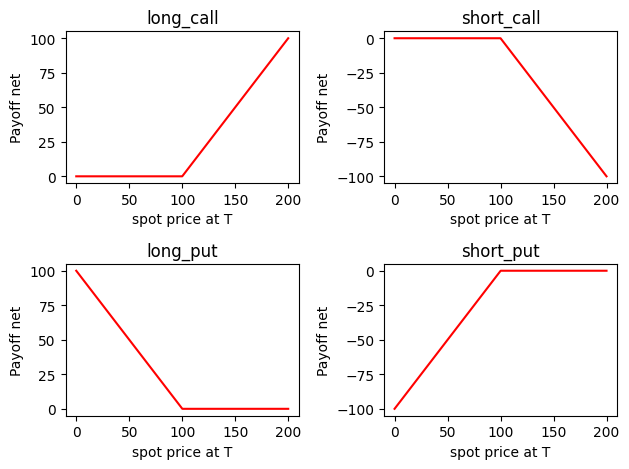

In [25]:
# Data preparation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from strategies import long_call, short_call, long_put, short_put

x_axis = np.linspace(0, 200, 1000)   # générer aléatoirement des floats sur un segment
strat = ["long_call", "short_call", "long_put", "short_put"]

fig, axs = plt.subplots(2, 2)   #matrice de figures
axs = axs.flatten()   #permet d'applatir la matrice des axes au lieu d'accéder par coordonnées on accède par indices

for i,p in enumerate(strat):
    match p:
        case "long_call":
            y_axis = long_call(x_axis, 100)
            
        case "short_call":
            y_axis = short_call(x_axis, 100)

        case "long_put":
            y_axis = long_put(x_axis, 100)
            
        case "short_put":
            y_axis = short_put(x_axis, 100)

    axs[i].set_xlabel("spot price at T")
    axs[i].set_ylabel("Payoff net")
    axs[i].set_title(p)   
    axs[i].plot(x_axis, y_axis, color="red")
    
plt.tight_layout() # ajuste automatiquement les espaces entre les figures
            
        

## STEP 2